# Matriz de Covarianza

* Por si sola nos explica posibles relaciones lineales en variables de un conjunto de datos.
* Clave para la reducción de un conjunto de datos.
* La Co-varianza, es como su nombre lo indica, 2 variables crecen mutuamente.
* Si en nuestra muestra, los datos varian mucho, es decir hay muchos valores dispersos, se dice que la varianza es alta.
* Si casi no hay dispersión, se dice que la varianza es baja.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Covarianza vs Correlaciones

* No, la matriz de covarianza y la matriz de correlaciones no son lo mismo, aunque están estrechamente relacionadas y ambas miden la relación entre variables.
* Matriz de covarianza:
  - Qué mide: Cuánto varían conjuntamente dos variables.
  - Valor: Puede tomar cualquier valor real (positivo, negativo o cero).
  - Escala: Depende de las unidades originales de las variables, por lo tanto no está normalizada.
* Matriz de correlaciones
  - Qué mide: La fuerza y dirección de la relación lineal entre variables.
  - Valor: Siempre entre -1 y 1.
  - Escala: Normalizada, es decir, no depende de las unidades de medida.
  - Se obtiene a partir de la matriz de covarianza dividiendo cada elemento cov(𝑋,𝑌) por el producto de las desviaciones estándar de X y Y.

$$
\text{Cov}(X, Y) = \frac{1}{n - 1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$

$$
\mathbf{\Sigma} =
\begin{bmatrix}
\text{Cov}(X_1, X_1) & \text{Cov}(X_1, X_2) & \cdots & \text{Cov}(X_1, X_p) \\
\text{Cov}(X_2, X_1) & \text{Cov}(X_2, X_2) & \cdots & \text{Cov}(X_2, X_p) \\
\vdots & \vdots & \ddots & \vdots \\
\text{Cov}(X_p, X_1) & \text{Cov}(X_p, X_2) & \cdots & \text{Cov}(X_p, X_p)
\end{bmatrix}
$$

$$
\rho(X, Y) = \frac{\text{Cov}(X, Y)}{\sigma_X \sigma_Y}
$$

$$
\mathbf{R} =
\begin{bmatrix}
1 & \rho_{12} & \cdots & \rho_{1p} \\
\rho_{21} & 1 & \cdots & \rho_{2p} \\
\vdots & \vdots & \ddots & \vdots \\
\rho_{p1} & \rho_{p2} & \cdots & 1
\end{bmatrix}
$$

$$
\mathbf{R} = \mathbf{D}^{-1} \mathbf{\Sigma} \mathbf{D}^{-1}
$$

$$
\mathbf{D} =
\begin{bmatrix}
\sigma_1 & 0 & \cdots & 0 \\
0 & \sigma_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \sigma_p
\end{bmatrix}
$$

* ¿Cuándo usar la matriz de covarianza?
  - Te interesa la magnitud real de la variabilidad conjunta (en las unidades originales de las variables).
  - Estás trabajando con variables en la misma escala (por ejemplo, todas en metros o segundos).
  - Vas a realizar métodos como: Análisis de componentes principales (PCA) sin normalizar, Modelado de errores en series temporales o modelos estructurales y Modelos donde la escala absoluta importa.
* No usar:
  - Las variables están en diferentes escalas o unidades (ej. peso en kg y altura en cm), porque la covarianza estaría distorsionada.

* ¿Cuándo usar la matriz de correlación?
  - Las variables están en diferentes escalas o unidades.
  - Te interesa la fuerza y dirección de la relación lineal entre variables, sin importar la escala.
  - Estás realizando: Análisis exploratorio de datos, PCA con datos normalizados (frecuente en machine learning), Visualización de relaciones (ej. mapas de calor), Modelos donde solo importa la relación relativa.

* No adecuada:
  - Quieres conservar las unidades originales en el análisis (ej. en modelos físicos o financieros detallados).

***Notas***
* Si tienes la matriz de covarianza y las desviaciones estándar de las variables, puedes construir la matriz de correlación.
* A la inversa, si tienes la matriz de correlación y conoces las desviaciones estándar, puedes reconstruir la matriz de covarianza.

### Varianza y Desviación Estándar con Pandas.

* Contexto:
  - (0)Edad
  - (1) Gastos mensuales en Medicina
  - (2) Gastos mensuales en Educación
  - (3) Gastos mensuales en Cacahuates

In [7]:
# Quitar la notación cientifica
pd.options.display.float_format = '{:.2f}'.format

datos = {
    "edad" : [35,50,22,45,18,75,55,20,23,49],
    "medicina": [200, 1500, 150, 250, 0, 2500, 1400, 50, 0, 600],
    "educacion": [1200, 0, 7500, 2200, 8300, 0, 0, 4900, 5100, 800],
    "cacahuates": [10, 15, 0, 10, 20, 10, 20, 10, 15, 0]
}
datos = pd.DataFrame(datos)
datos.aggregate(["std", "var", "mean"])

,edad,medicina,educacion,cacahuates
std,18.77,851.49,3198.61,6.99
var,352.40,725027.78,10231111.11,48.89
mean,39.20,665.00,3000.00,11.00


### Gráficando Desviación Estándar

* La linea punteada en azul, es el promedio de cada sección.
* Las lineas en grises es el promedio más menos la desvación.
* Todos los que esten fuera podrían ser data outliers? o simplemente están muy dispersos.

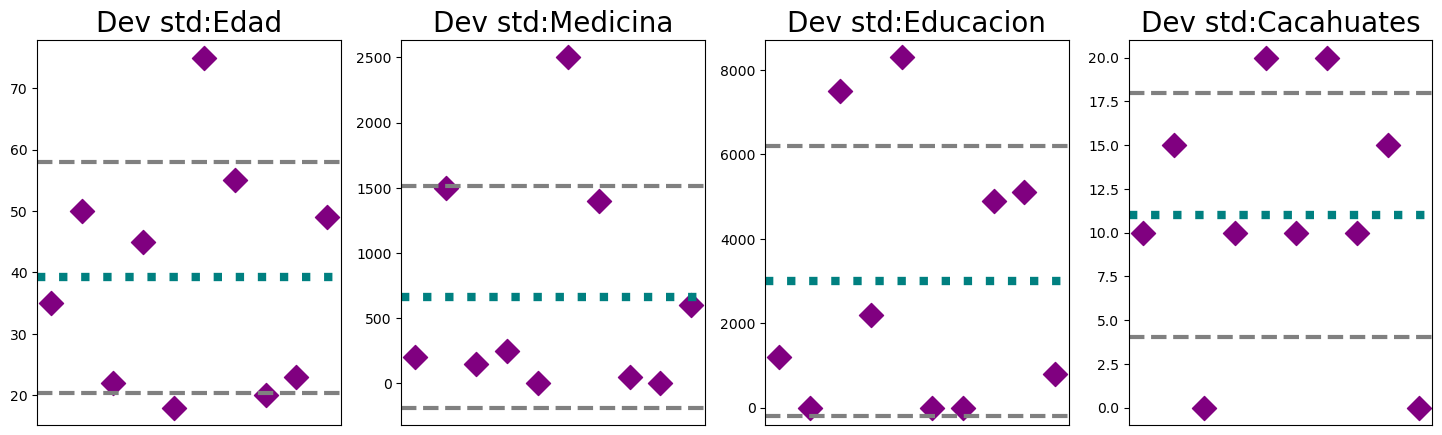

In [10]:
def subgrafica_std(datos, columna, fig, posicion):
    ax = fig.add_subplot(1,4,posicion)
    media = datos[columna].mean()
    # Calculando media y desviación estandar
    std = datos[columna].std()
    
    # Gráficando Datos
    ax.scatter(
        range(len(datos[columna])),
        datos[columna],
        marker="D",
        s=150,
        color="purple"
    )
    # Gráficando media y desviación estándar
    ax.axhline(y=media+std, color="gray", linestyle="--", linewidth=3)
    ax.axhline(y=media, color="teal", linestyle=":", linewidth=6)
    ax.axhline(y=media-std, color="gray", linestyle="--", linewidth=3)
    ax.set_title("Dev std:" + columna.capitalize(), fontsize=20)
    ax.set_xticks(range(len(datos[columna])))
    ax.get_xaxis().set_visible(False)

# Desviaciones estándar para todas las columnas
fig = plt.figure(figsize=(18,5))

subgrafica_std(datos, "edad", fig, 1)
subgrafica_std(datos, "medicina", fig, 2)
subgrafica_std(datos, "educacion", fig, 3)
subgrafica_std(datos, "cacahuates", fig, 4)
plt.show()

### Covarianza

* Hay que estandarizar los datos, ya que en algunos valores podría ser dificil interpretar las magnitudes entre 2 variables diferentes.

In [11]:
print(datos.var())
datos.cov()

edad              352.40
medicina       725027.78
educacion    10231111.11
cacahuates         48.89
dtype: float64


,edad,medicina,educacion,cacahuates
edad,352.40,14530.00,-51788.89,-0.78
medicina,14530.00,725027.78,-1923333.33,816.67
educacion,-51788.89,-1923333.33,10231111.11,-500.00
cacahuates,-0.78,816.67,-500.00,48.89


### Gráficando Covarianza

* Entre la edad crece más se gasta en medicina, tiene sentido.
* Entre menos edad, mas se gasta en educacion, también tiene sentido.
* 

             edad  medicina
edad       352.40  14530.00
medicina 14530.00 725027.78 

               edad   educacion
edad         352.40   -51788.89
educacion -51788.89 10231111.11 

             edad  cacahuates
edad       352.40       -0.78
cacahuates  -0.78       48.89 





             medicina   educacion
medicina    725027.78 -1923333.33
educacion -1923333.33 10231111.11 

            medicina  cacahuates
medicina   725027.78      816.67
cacahuates    816.67       48.89 

             educacion  cacahuates
educacion  10231111.11     -500.00
cacahuates     -500.00       48.89 



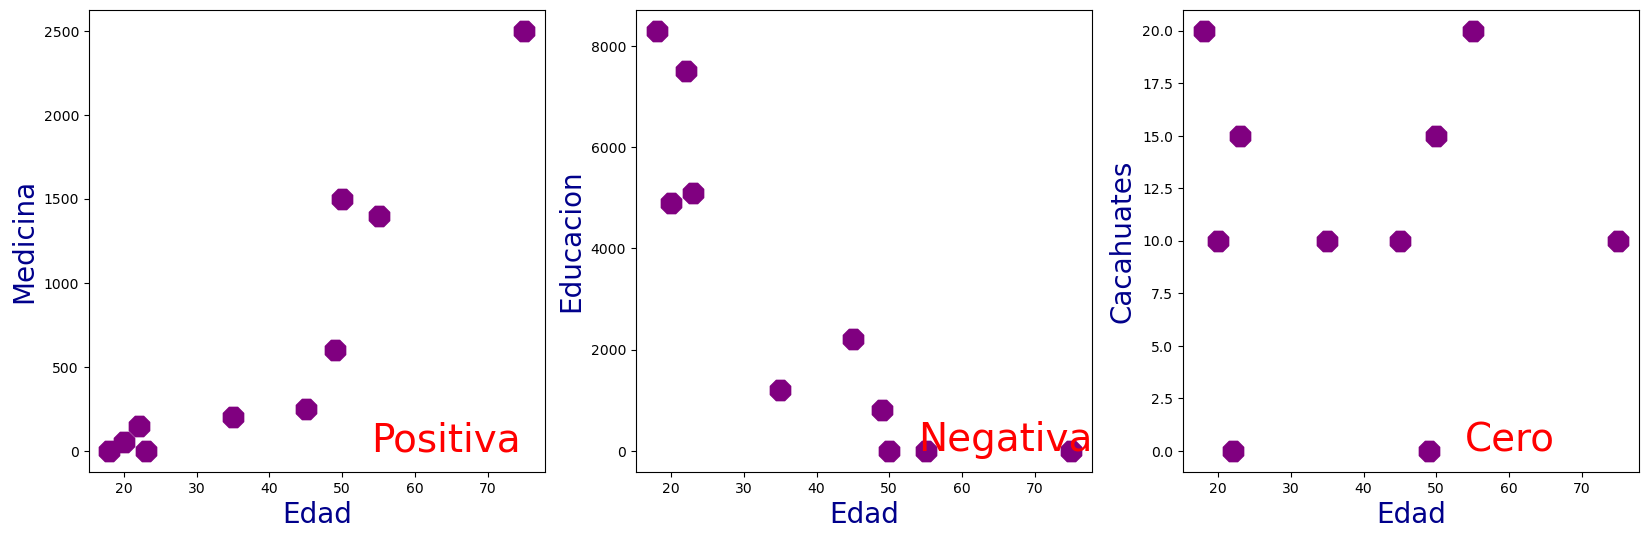

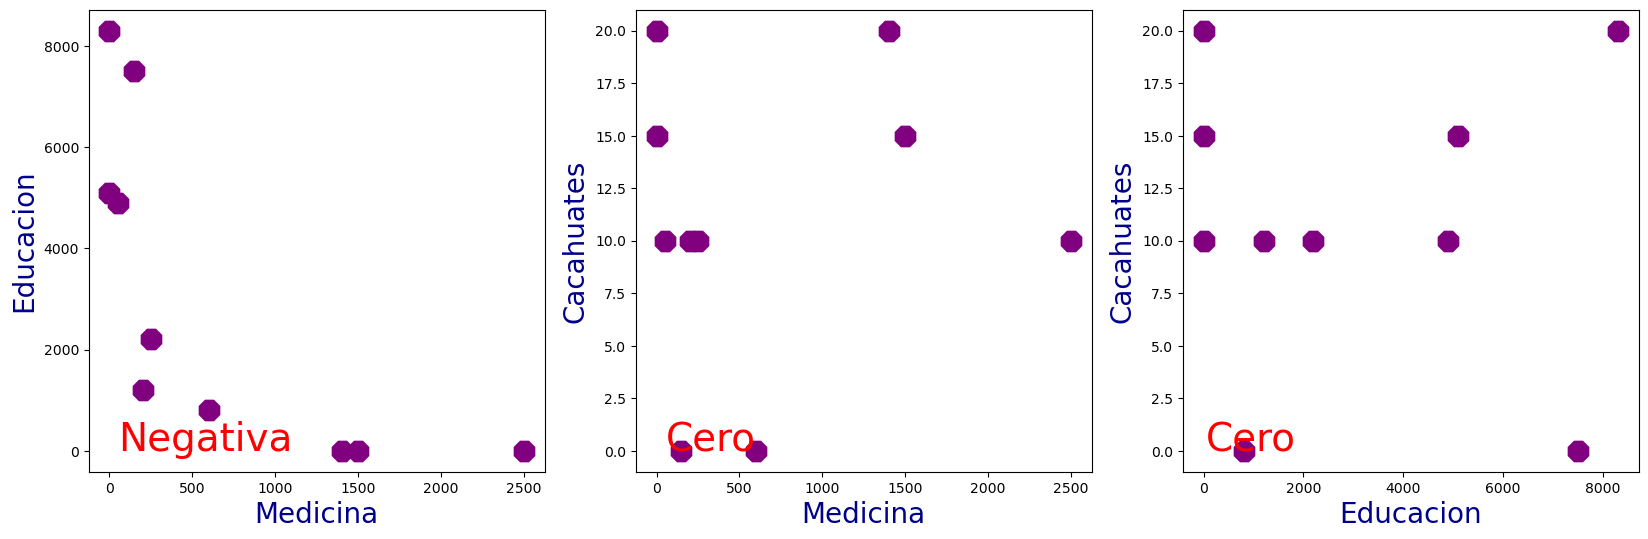

In [14]:
def subgrafica_dispersion(datos, col_a, col_b, fig, posicion, texto):
    ax = fig.add_subplot(1,3,posicion)
    ax.scatter(
        datos[col_a], 
        datos[col_b],
        marker="8",
        s=250,
        color="purple")
    ax.set_xlabel(col_a.capitalize(), fontsize=20, color="darkblue")
    ax.set_ylabel(col_b.capitalize(), fontsize=20, color="darkblue")
    ax.text(54,0,texto, fontsize=28, color="red")

# Impresión de matrices de covarianza
print(datos[["edad", "medicina"]].cov(), "\n")
print(datos[["edad", "educacion"]].cov(), "\n")
print(datos[["edad", "cacahuates"]].cov(), "\n")

# Gráficas
fig = plt.figure(figsize=(20,6))
subgrafica_dispersion(datos, "edad", "medicina", fig, 1, "Positiva")
subgrafica_dispersion(datos, "edad", "educacion", fig, 2, "Negativa")
subgrafica_dispersion(datos, "edad", "cacahuates", fig, 3, "Cero")

# Impresión de matrices de covarianza
print("\n"*3)
print(datos[["medicina", "educacion"]].cov(), "\n")
print(datos[["medicina", "cacahuates"]].cov(), "\n")
print(datos[["educacion", "cacahuates"]].cov(), "\n")

# Gráficas
fig = plt.figure(figsize=(20,6))
subgrafica_dispersion(datos, "medicina", "educacion", fig, 1, "Negativa")
subgrafica_dispersion(datos, "medicina", "cacahuates", fig, 2, "Cero")
subgrafica_dispersion(datos, "educacion", "cacahuates", fig, 3, "Cero")
plt.show()